# 03 — Model Training & Evaluation

Trains the Random Forest baseline and the multiclass XGBoost model, evaluates both, and saves the final model + label encoder. **The XGBoost cell is the slow one** — budget real time for this on CPU (this took ~80 minutes at n_estimators=300 during development). Smoke-test with a small n_estimators first if you've changed anything upstream.

In [1]:
import sys
sys.path.append('..')

import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = np.load('../data/X_fingerprints.npy')
y = np.load('../data/y_labels.npy', allow_pickle=True)
print(X.shape, y.shape)


(191808, 4096) (191808,)


In [2]:
# Drop rows with invalid SMILES (either half of the pair all-zero)
valid_mask = ~((X[:, :2048].sum(axis=1) == 0) | (X[:, 2048:].sum(axis=1) == 0))
print(f"Dropping {(~valid_mask).sum()} rows ({(~valid_mask).sum()/len(X):.2%})")

X_valid = X[valid_mask]
y_valid = y[valid_mask].astype(str)  # avoids int/str sort crash in sklearn


Dropping 171 rows (0.09%)


In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_valid)
print(f"Classes: {len(le.classes_)}")


Classes: 54


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_valid, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)


(134145, 4096) (28746, 4096) (28746, 4096)


## Random Forest baseline

In [5]:
from src.model import train_random_forest, evaluate_model

rf = train_random_forest(X_train, y_train)
rf_metrics = evaluate_model(rf, X_val, y_val, le)


              precision    recall  f1-score   support

          10       0.79      0.97      0.87        95
          11       0.72      0.49      0.58        47
          12       0.84      0.77      0.81        35
          14       0.98      0.98      0.98        54
          15       0.67      0.97      0.79        30
          16       0.86      0.89      0.88       812
          19       1.00      0.81      0.90        16
           2       0.80      0.67      0.73        48
          20       0.80      0.80      0.80       921
          21       0.98      0.89      0.93        64
          24       1.00      1.00      1.00        27
          25       0.95      0.85      0.90       108
          27       0.98      0.97      0.98       141
          29       0.83      0.83      0.83        48
           3       1.00      1.00      1.00        77
          30       0.82      0.81      0.81        93
          32       0.80      0.99      0.89       152
          33       0.67    

## XGBoost (final model)

In [6]:
from src.model import train_xgboost

model = train_xgboost(X_train, y_train, X_val, y_val, num_class=len(le.classes_))
test_metrics = evaluate_model(model, X_test, y_test, le)


[0]	validation_0-mlogloss:3.47715
[50]	validation_0-mlogloss:1.18300
[100]	validation_0-mlogloss:0.84022
[150]	validation_0-mlogloss:0.70773
[200]	validation_0-mlogloss:0.62612
[250]	validation_0-mlogloss:0.56770
[299]	validation_0-mlogloss:0.52358
              precision    recall  f1-score   support

          10       0.82      1.00      0.90        94
          11       0.42      0.79      0.54        47
          12       0.78      1.00      0.88        36
          14       0.95      1.00      0.97        54
          15       0.67      0.97      0.79        29
          16       0.87      0.98      0.92       812
          19       0.89      0.94      0.91        17
           2       0.65      0.94      0.77        49
          20       0.78      0.95      0.85       921
          21       0.90      0.97      0.93        64
          24       0.93      1.00      0.96        27
          25       0.89      1.00      0.94       107
          27       0.95      0.99      0.97     

## Confusion matrices

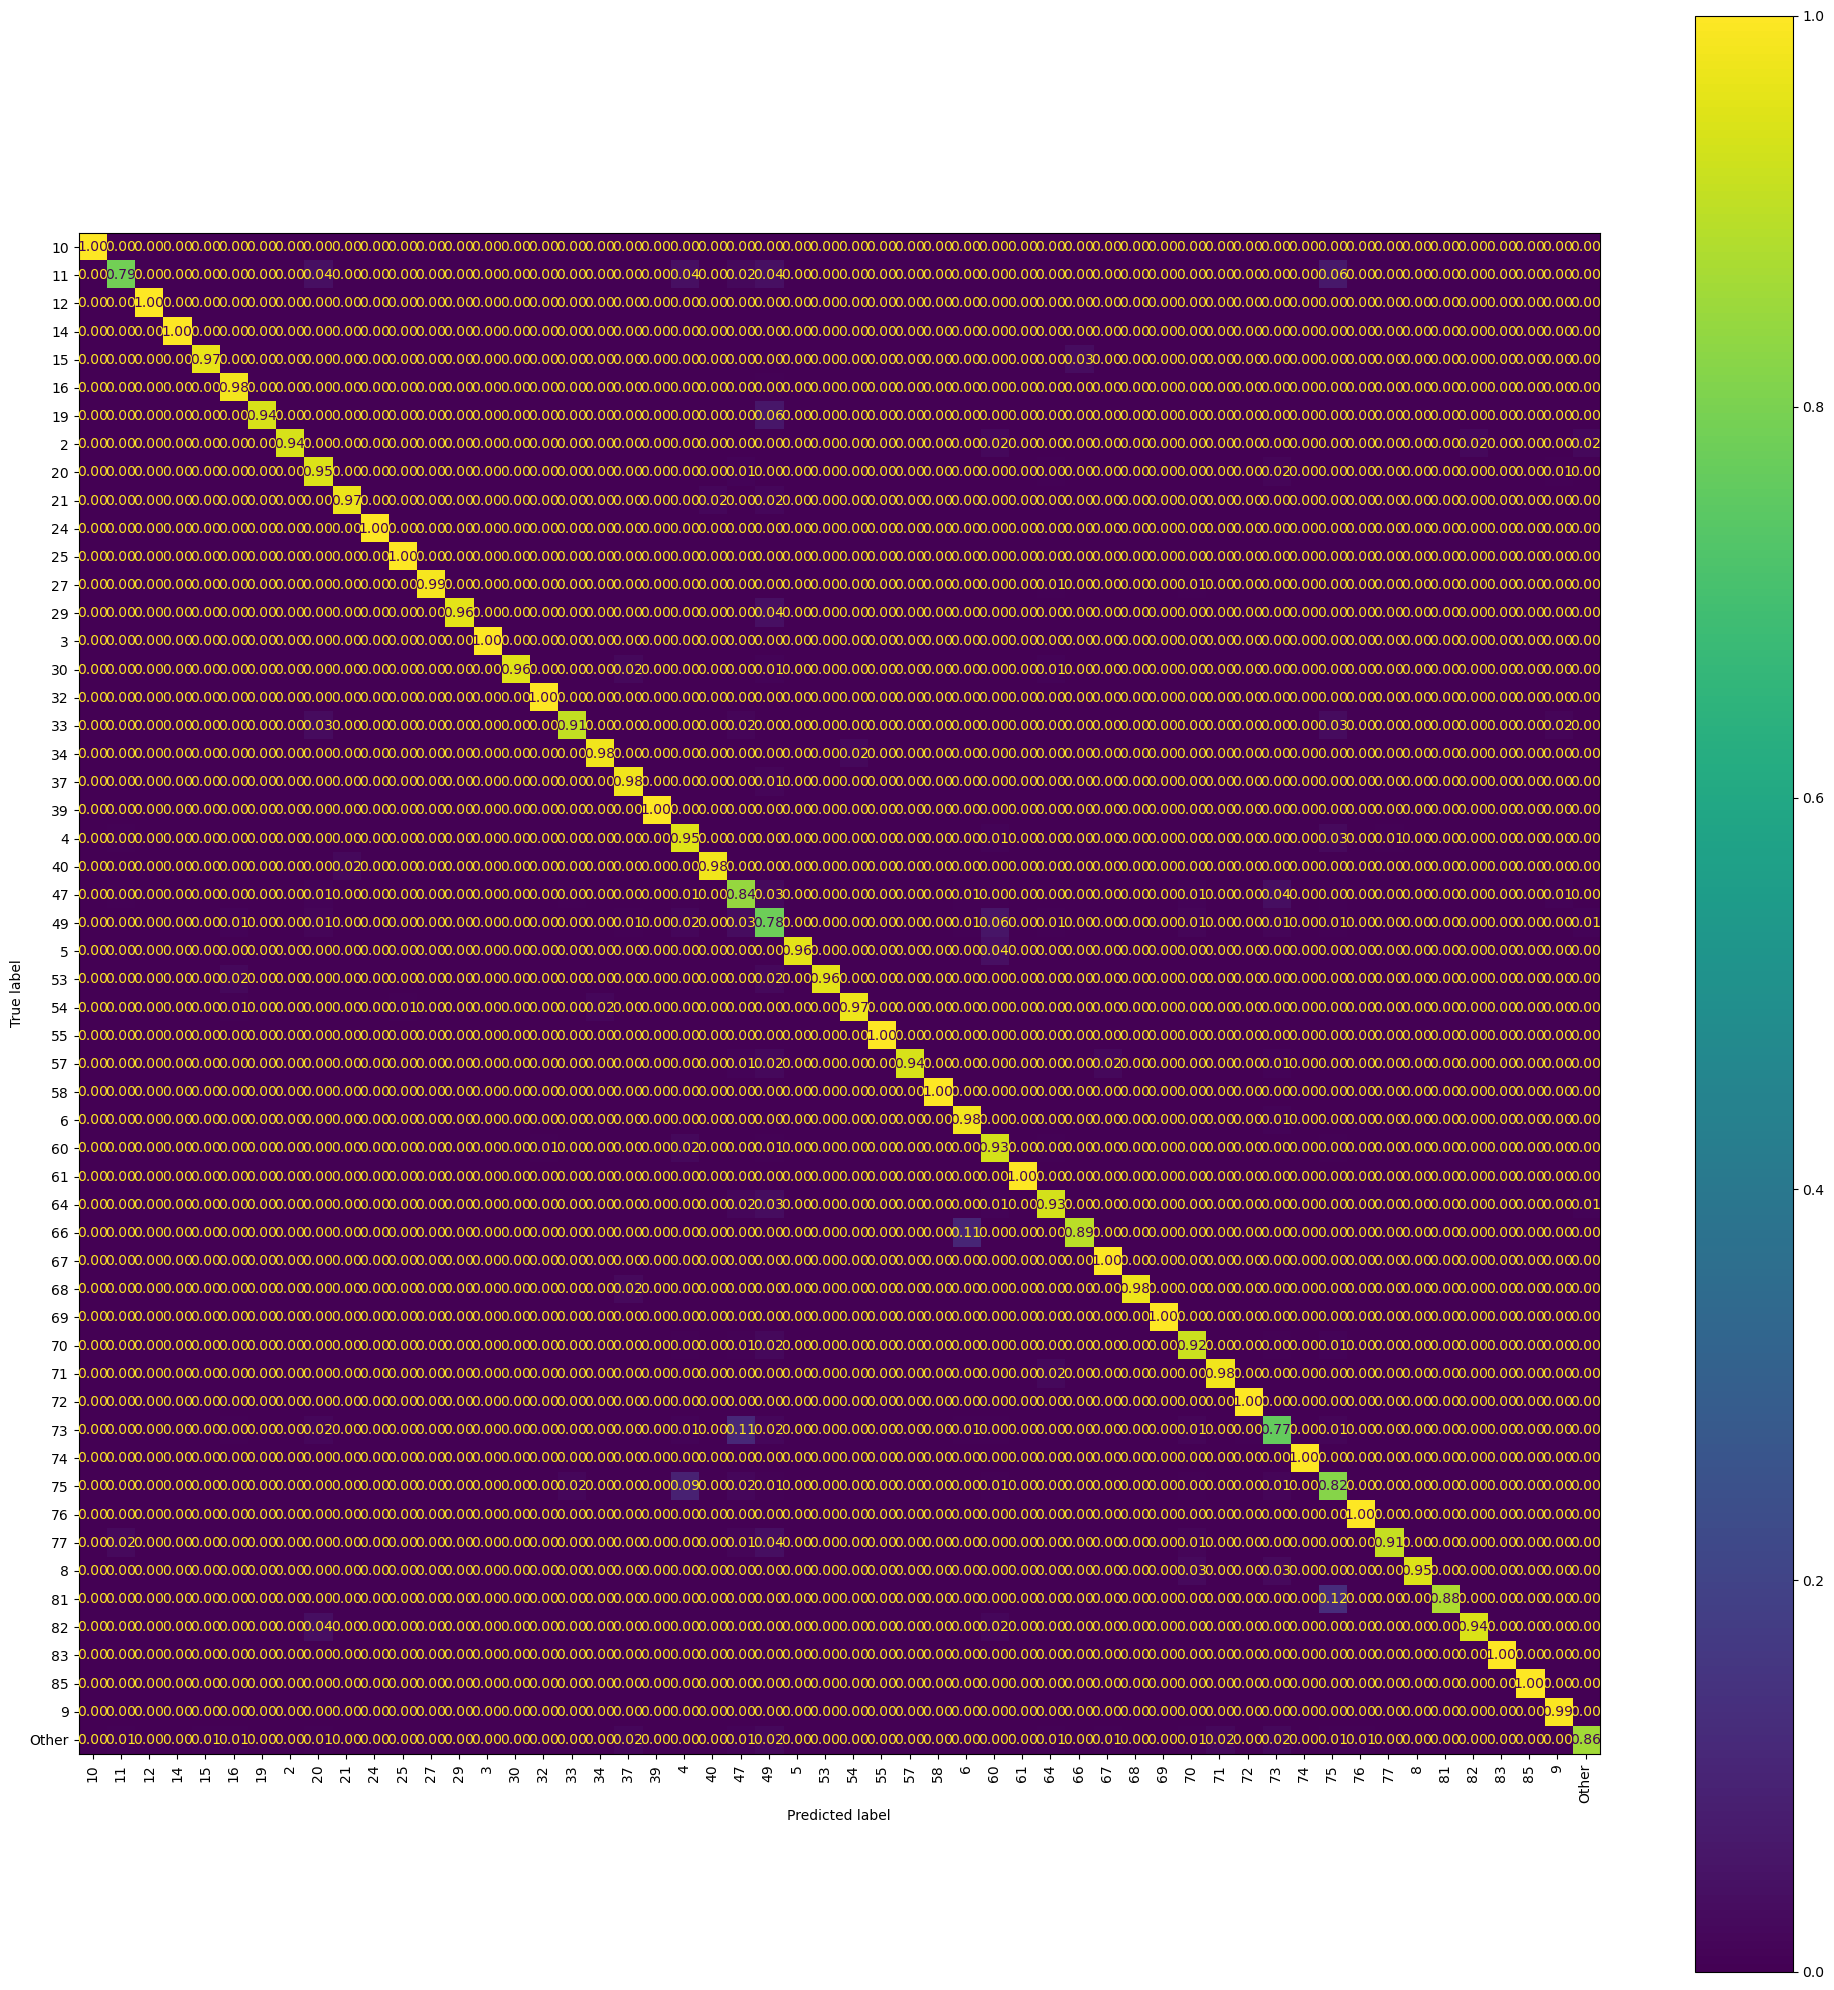

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = test_metrics['y_pred']

cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=90, values_format='.2f', colorbar=True)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()


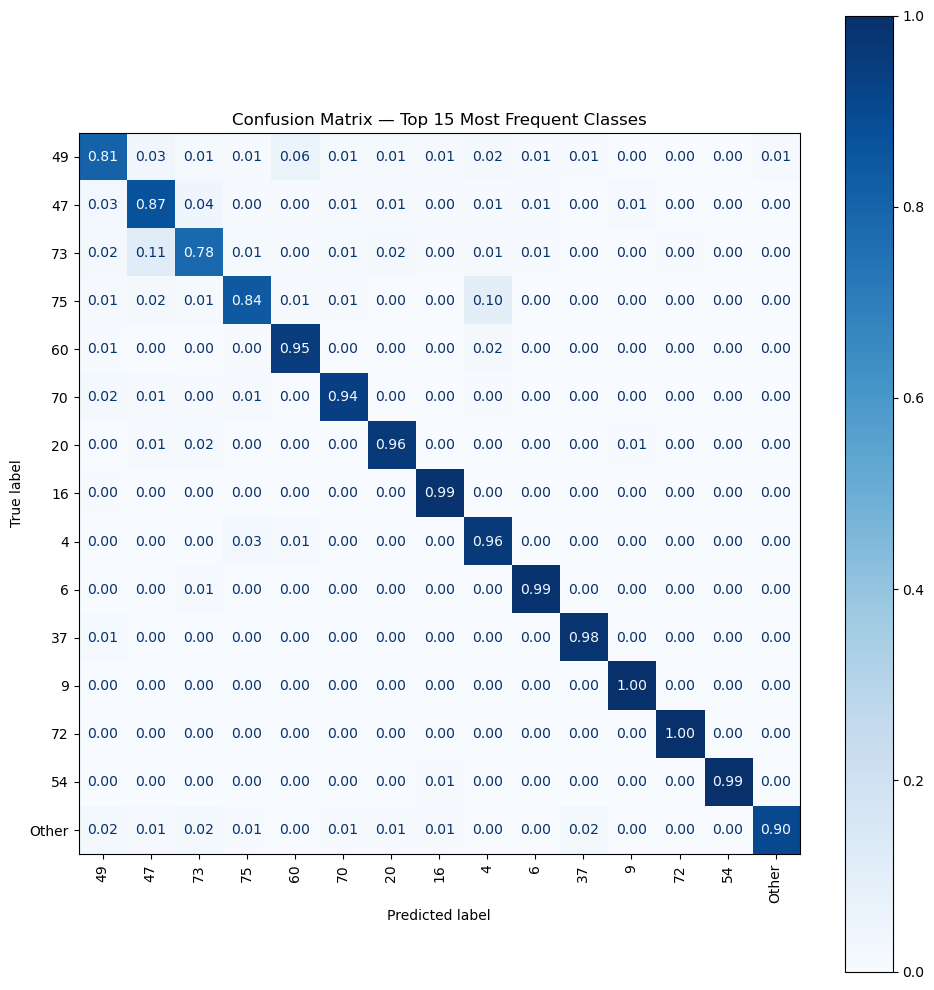

In [8]:
N = 15
top_classes_idx = np.argsort(-np.bincount(y_test, minlength=len(le.classes_)))[:N]
top_class_names = le.classes_[top_classes_idx]

mask = np.isin(y_test, top_classes_idx)
y_test_top = y_test[mask]
y_pred_top = y_pred[mask]

cm_top = confusion_matrix(y_test_top, y_pred_top, labels=top_classes_idx, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(cm_top, display_labels=top_class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format='.2f', colorbar=True, cmap='Blues')
plt.title(f'Confusion Matrix — Top {N} Most Frequent Classes')
plt.tight_layout()
plt.savefig('../models/confusion_matrix_top15.png', dpi=150)
plt.show()


## Save the model

In [9]:
import joblib

joblib.dump(model, '../models/ddi_xgb.joblib')
joblib.dump(le, '../models/label_encoder.joblib')
print('Saved.')


Saved.
